In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom, norm, ttest_1samp, t
import math
import arviz as az

In [2]:
np.random.seed(1)

In [3]:
# Creating parameter grid for a manual Beta–Binomial example.

theta = np.linspace(0, 1, 500)

In [4]:
# Creating priors.

uniform_prior = beta.pdf(theta, 1, 1)
informative_prior = beta.pdf(theta, 8, 2)

# Creating observed data.

heads = 7
tails = 3

# Creating posterior parameters.

uniform_post = beta.pdf(theta, 1 + heads, 1 + tails)
informative_post = beta.pdf(theta, 8 + heads, 2 + tails)

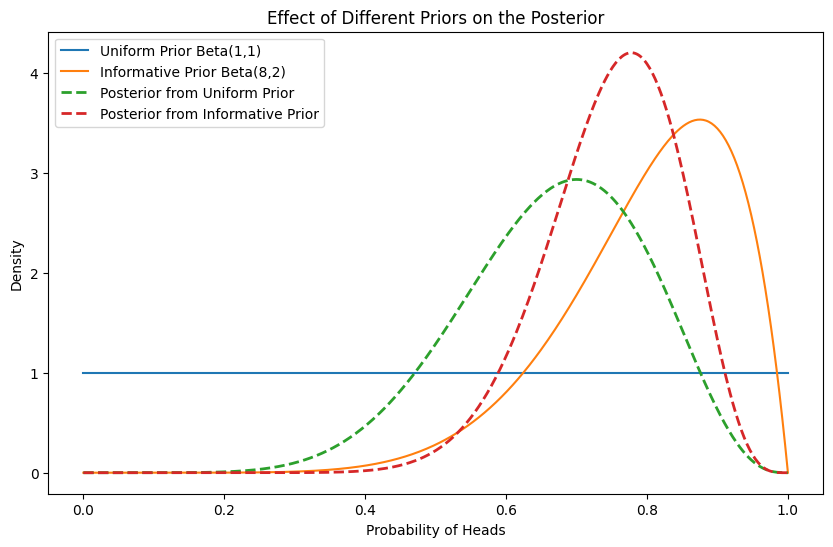

In [5]:
# Visualizing priors and posteriors.

plt.figure(figsize=(10, 6))

plt.plot(theta, uniform_prior, label="Uniform Prior Beta(1,1)")
plt.plot(theta, informative_prior, label="Informative Prior Beta(8,2)")

plt.plot(theta, uniform_post, "--", linewidth=2,
         label="Posterior from Uniform Prior")

plt.plot(theta, informative_post, "--", linewidth=2,
         label="Posterior from Informative Prior")

plt.xlabel("Probability of Heads")
plt.ylabel("Density")
plt.title("Effect of Different Priors on the Posterior")

plt.legend()

plt.show()

#### Beta-Binomial Conjugate Model

In [6]:
# Defining the prior: Beta(alpha, beta).

alpha_prior = 2
beta_prior = 2

# Creating observed data.

n = 10
heads = 7
tails = n - heads

# Compute posterior parameters analytically.

alpha_post = alpha_prior + heads
beta_post = beta_prior + tails

print("Posterior parameters:","\nAlpha: ", alpha_post, "\nBeta: ", beta_post)

# Creating theta grid.

theta = np.linspace(0, 1, 500)

Posterior parameters: 
Alpha:  9 
Beta:  5


In [7]:
# Computing prior density.

prior = beta.pdf(theta, alpha_prior, beta_prior)

# Computing likelihood.

likelihood = binom.pmf(heads, n, theta)

# Normalizing likelihood for visualization.

likelihood /= likelihood.max()

# Computing posterior density.

posterior = beta.pdf(theta, alpha_post, beta_post)

# Posterior summary statistics

posterior_mean = alpha_post / (alpha_post + beta_post)

posterior_variance = (
    alpha_post * beta_post
    /
    ((alpha_post + beta_post) ** 2 * (alpha_post + beta_post + 1))
)

print("Posterior mean: ", posterior_mean)
print("Posterior variance: ", posterior_variance)


Posterior mean:  0.6428571428571429
Posterior variance:  0.015306122448979591


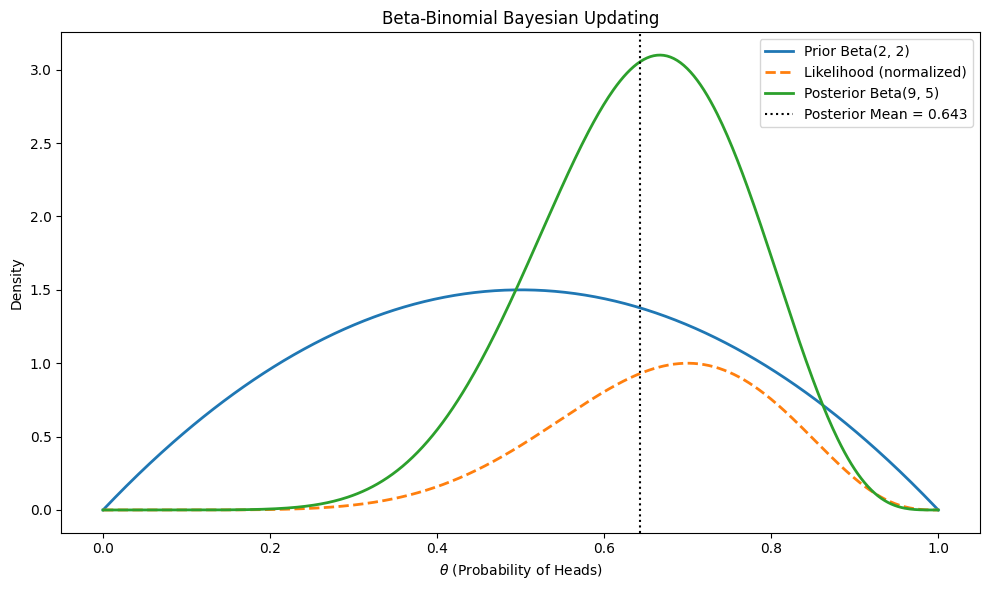

In [8]:
# Visualizing prior, likelihood, and posterior

plt.figure(figsize=(10, 6))

plt.plot(
    theta,
    prior,
    label=f"Prior Beta({alpha_prior}, {beta_prior})",
    linewidth=2
)

plt.plot(
    theta,
    likelihood,
    label="Likelihood (normalized)",
    linestyle="--",
    linewidth=2
)

plt.plot(
    theta,
    posterior,
    label=f"Posterior Beta({alpha_post}, {beta_post})",
    linewidth=2
)

plt.axvline(
    posterior_mean,
    color="black",
    linestyle=":",
    label=f"Posterior Mean = {posterior_mean:.3f}"
)

plt.title("Beta-Binomial Bayesian Updating")
plt.xlabel(r"$\theta$ (Probability of Heads)")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

#### Normal–Normal Conjugate Model

In [9]:
# Defining the true parameters used to simulate the data.

true_mean = 520
known_variance = 25
known_std = np.sqrt(known_variance)

# Simulating Gaussian data.

n = 10

data = np.random.normal(
    loc=true_mean,
    scale=known_std,
    size=n
)

# Computing sample statistics.

sample_mean = np.mean(data)

print("Sample statistics:", "\nSample size: ", n, "\nSample mean: ", sample_mean)

Sample statistics: 
Sample size:  10 
Sample mean:  519.5142955459696


In [10]:
# Defining the Normal prior.

prior_mean = 500
prior_variance = 100
prior_std = np.sqrt(prior_variance)

# Computing analytical posterior parameters.

posterior_variance = 1 / ((1 / prior_variance) + (n / known_variance))

posterior_mean = posterior_variance * ((prior_mean / prior_variance) + (n * sample_mean / known_variance))

posterior_std = np.sqrt(posterior_variance)

print("Posterior parameters:", "\nPosterior mean", posterior_mean, "\nPosterior variance: ", posterior_variance)

Posterior parameters: 
Posterior mean 519.0383371180192 
Posterior variance:  2.4390243902439024


In [11]:
# Creating values for plotting.

mu = np.linspace(470, 550, 500)

# Computing prior density.

prior = norm.pdf(mu, loc=prior_mean, scale=prior_std)

# Computing posterior density.

posterior = norm.pdf( mu, loc=posterior_mean, scale=posterior_std)

# Computing likelihood.

likelihood = norm.pdf( mu, loc=sample_mean, scale=known_std / np.sqrt(n))

# Normalizing the likelihood for visualization.

likelihood /= likelihood.max()

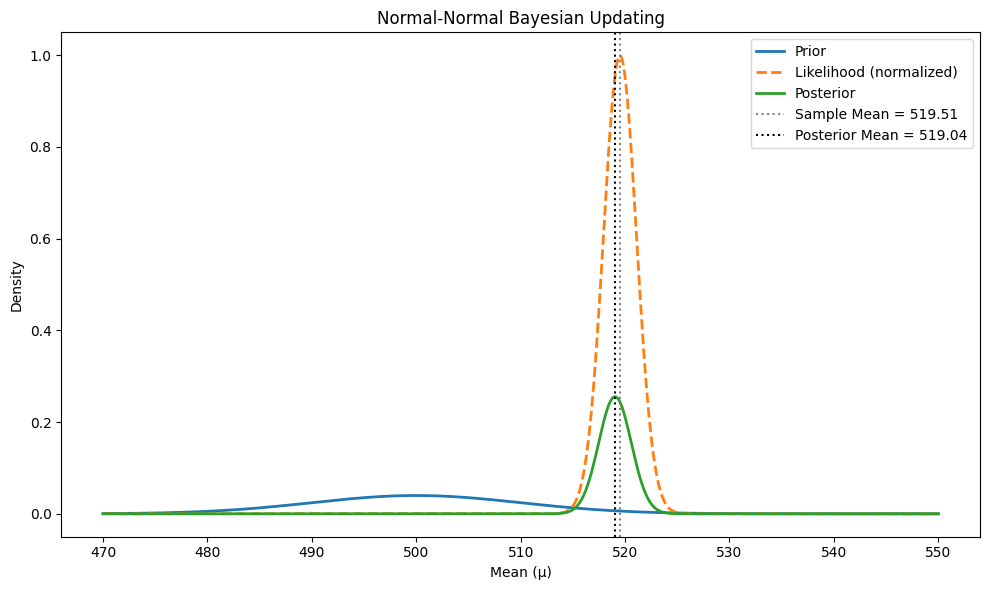

In [12]:
# Visualizing prior, likelihood, and posterior.

plt.figure(figsize=(10,6))

plt.plot(
    mu,
    prior,
    label="Prior",
    linewidth=2
)

plt.plot(
    mu,
    likelihood,
    "--",
    label="Likelihood (normalized)",
    linewidth=2
)

plt.plot(
    mu,
    posterior,
    label="Posterior",
    linewidth=2
)

plt.axvline(
    sample_mean,
    color="gray",
    linestyle=":",
    label=f"Sample Mean = {sample_mean:.2f}"
)

plt.axvline(
    posterior_mean,
    color="black",
    linestyle=":",
    label=f"Posterior Mean = {posterior_mean:.2f}"
)

plt.title("Normal-Normal Bayesian Updating")
plt.xlabel("Mean (μ)")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

#### Simulate Binomial data

In [13]:
# Defining the true parameter.

true_theta = 0.70

# Simulating Binomial data.

n = 20

coin_flips = np.random.binomial(n=1, p=true_theta, size=n)

heads = np.sum(coin_flips)
tails = n - heads

# Binomial Data

print("True probability: ", true_theta)
print("Heads: ", heads)
print("Tails: ", tails)

# Defining the prior.

alpha_prior = 2
beta_prior = 2

# Recovering the posterior.

alpha_post = alpha_prior + heads
beta_post = beta_prior + tails

posterior_mean_beta = alpha_post / (alpha_post + beta_post)

print("Posterior Alpha: ", alpha_post)
print("Posterior Beta: ", beta_post)
print("Posterior Mean: ", posterior_mean_beta)

# Drawing posterior samples for validation.

posterior_samples_beta = np.random.beta(alpha_post, beta_post, size=10000)

True probability:  0.7
Heads:  14
Tails:  6
Posterior Alpha:  16
Posterior Beta:  8
Posterior Mean:  0.6666666666666666


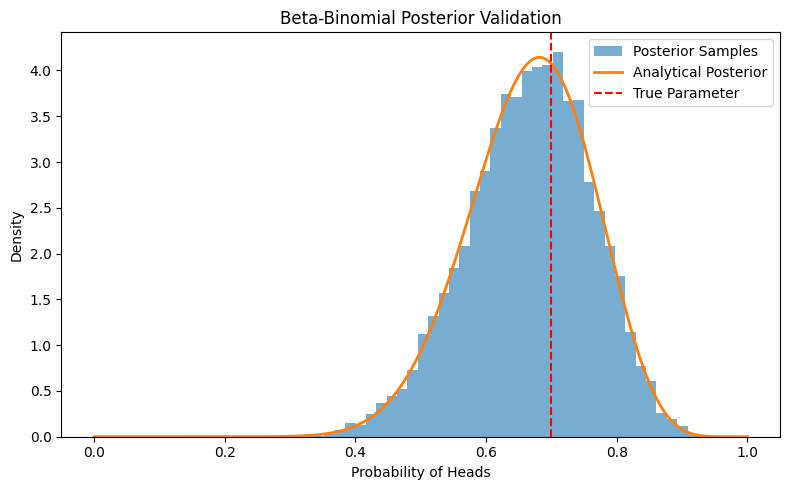

In [14]:
# Visualizing posterior samples.

theta = np.linspace(0, 1, 500)

plt.figure(figsize=(8,5))

plt.hist(
    posterior_samples_beta,
    bins=40,
    density=True,
    alpha=0.6,
    label="Posterior Samples"
)

plt.plot(
    theta,
    beta.pdf(theta, alpha_post, beta_post),
    linewidth=2,
    label="Analytical Posterior"
)

plt.axvline(
    true_theta,
    color="red",
    linestyle="--",
    label="True Parameter"
)

plt.title("Beta-Binomial Posterior Validation")
plt.xlabel("Probability of Heads")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

#### Simulate Normal data

In [15]:
# Defining the true parameters.

true_mean = 520
known_variance = 25
known_std = np.sqrt(known_variance)

# Simulating Normal data.

n = 20

data = np.random.normal(loc=true_mean, scale=known_std, size=n)

sample_mean = np.mean(data)

# Normal Data

print("True Mean: ", true_mean)
print("Sample Mean: ", sample_mean)

# Defining the Normal prior.

prior_mean = 500
prior_variance = 100
prior_std = np.sqrt(prior_variance)

# Recovering the posterior.

posterior_variance = 1 / ((1 / prior_variance) + (n / known_variance))

posterior_mean = posterior_variance * ((prior_mean / prior_variance) + (n * sample_mean / known_variance))

posterior_std = np.sqrt(posterior_variance)

print("Posterior Mean: ", posterior_mean)
print("Posterior Variance: ", posterior_variance)

# Drawing posterior samples for validation.

posterior_samples_normal = np.random.normal(loc=posterior_mean, scale=posterior_std, size=10000)

True Mean:  520
Sample Mean:  519.928838070348
Posterior Mean:  519.6828030324424
Posterior Variance:  1.2345679012345678


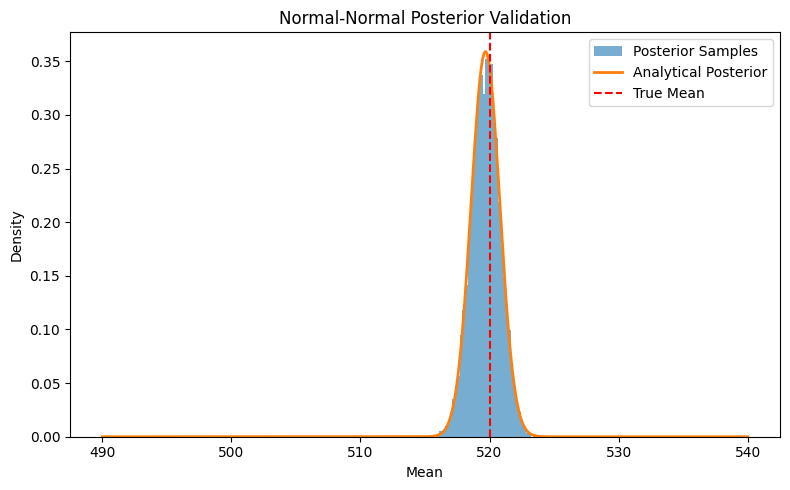

In [16]:
# Visualizing posterior samples.

mu = np.linspace(490, 540, 500)

plt.figure(figsize=(8,5))

plt.hist(
    posterior_samples_normal,
    bins=40,
    density=True,
    alpha=0.6,
    label="Posterior Samples"
)

plt.plot(
    mu,
    norm.pdf(mu, posterior_mean, posterior_std),
    linewidth=2,
    label="Analytical Posterior"
)

plt.axvline(
    true_mean,
    color="red",
    linestyle="--",
    label="True Mean"
)

plt.title("Normal-Normal Posterior Validation")
plt.xlabel("Mean")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

In [17]:
# Compare posterior means with the true parameters.

print("True Binomial Parameter: ", true_theta)
print("Posterior Mean (Binomial): ", posterior_mean_beta)
print("True Normal Mean: ", true_mean)
print("Posterior Mean (Normal): ", posterior_mean)

True Binomial Parameter:  0.7
Posterior Mean (Binomial):  0.6666666666666666
True Normal Mean:  520
Posterior Mean (Normal):  519.6828030324424


#### Bayesian vs Frequentist Interpretation

In [18]:
# Simulating Normal data.

true_mean = 50
known_variance = 25
known_std = np.sqrt(known_variance)

n = 30

data = np.random.normal(loc=true_mean, scale=known_std, size=n)

In [19]:
# Computing sample statistics.

sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)

print("Sample size: ", n)
print("Sample mean: ", sample_mean)
print("Sample standard deviation: ", sample_std)

Sample size:  30
Sample mean:  49.853250675305986
Sample standard deviation:  5.279036851325673


In [20]:
# Bayesian Inference

# Defining the Normal prior.

prior_mean = 95
prior_variance = 100
prior_std = np.sqrt(prior_variance)

# Computing posterior parameters.

posterior_variance = 1 / ((1 / prior_variance) + (n / known_variance))

posterior_mean = posterior_variance * ((prior_mean / prior_variance) + (n * sample_mean / known_variance))

posterior_std = np.sqrt(posterior_variance)

print("Posterior mean: ", posterior_mean)
print("Posterior variance: ", posterior_variance)

# Computing the 95% credible interval.

credible_interval = norm.interval(
    confidence=0.95,
    loc=posterior_mean,
    scale=posterior_std
)

print("95% credible interval: ", credible_interval)

Posterior mean:  50.226364306088584
Posterior variance:  0.8264462809917356
95% credible interval:  (np.float64(48.44457886559763), np.float64(52.00814974657954))


In [21]:
# Frequentist Analysis

# Computing the 95% confidence interval.

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=n - 1,
    loc=sample_mean,
    scale=stats.sem(data)
)

print("95% confidence interval: ", confidence_interval)

# Performing a one-sample t-test.

t_statistic, p_value = stats.ttest_1samp(data, popmean=true_mean)

print("t-statistic: ", t_statistic)
print("p-value: ", p_value)

NameError: name 'stats' is not defined

In [ ]:
# Visualizing and comparing frequentist and Bayesian Estimate

mu = np.linspace(90, 110, 500)

prior = norm.pdf(mu, prior_mean, prior_std)

posterior = norm.pdf(mu, posterior_mean, posterior_std)

plt.figure(figsize=(10, 6))

plt.plot(
    mu,
    prior,
    label="Prior",
    linewidth=2
)

plt.plot(
    mu,
    posterior,
    label="Posterior",
    linewidth=2
)

plt.axvline(
    sample_mean,
    color="black",
    linestyle="--",
    label="Sample Mean"
)

plt.axvline(
    true_mean,
    color="red",
    linestyle=":",
    label="True Mean"
)

plt.title("Bayesian Posterior vs Frequentist Estimate")
plt.xlabel("Mean")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

print("True mean: ", true_mean)
print("Sample mean: ", sample_mean)
print("Posterior mean: ", posterior_mean)
print("95% credible interval: ", credible_interval)
print("95% confidence interval: ", confidence_interval)

#### 95% Credible Interval

In [ ]:
# Defining the true parameter.

true_mean = 100

# Defining the known variance.

known_variance = 25
known_std = np.sqrt(known_variance)

# Defining the prior.

prior_mean = 95
prior_variance = 100

# Setting the simulation parameters.

n = 30
n_simulations = 1000

# Counting how many credible intervals contain the true mean.

count_contains_true = 0

In [ ]:
# Running the simulation.

for _ in range(n_simulations):

    # Simulating Normal data.

    data = np.random.normal(loc=true_mean, scale=known_std, size=n)

    # Computing the sample mean.

    sample_mean = np.mean(data)

    # Computing the posterior parameters.

    posterior_variance = 1 / ((1 / prior_variance) + (n / known_variance))

    posterior_mean = posterior_variance * ((prior_mean / prior_variance) + (n * sample_mean / known_variance))

    posterior_std = np.sqrt(posterior_variance)

    # Computing the 95% credible interval.

    credible_interval = norm.interval(confidence=0.95, loc=posterior_mean, scale=posterior_std)

    # Checking whether the interval contains the true mean.

    if credible_interval[0] <= true_mean <= credible_interval[1]:
        count_contains_true += 1

# Computing the coverage probability.

coverage = count_contains_true / n_simulations

print("Number of simulations: ", n_simulations)
print("Intervals containing the true mean: ", count_contains_true)
print("Coverage probability: ", coverage)

In [ ]:
# Defining the true parameters.

true_mean = 100
known_variance = 25
known_std = np.sqrt(known_variance)

# Simulating Normal data.

n = 30

observed_data = np.random.normal(loc=true_mean, scale=known_std, size=n)

# Computing the sample mean.

sample_mean = np.mean(observed_data)

print("Sample size: ", n)
print("Sample mean: ", sample_mean)

In [ ]:
# Defining the Normal prior.

prior_mean = 95
prior_variance = 100

# Computing the posterior parameters.

posterior_variance = 1 / ((1 / prior_variance) + (n / known_variance))

posterior_mean = posterior_variance * ( (prior_mean / prior_variance) + (n * sample_mean / known_variance))

posterior_std = np.sqrt(posterior_variance)

print("Posterior mean: ", posterior_mean)
print("Posterior standard deviation: ", posterior_std)

In [ ]:
# Drawing posterior samples.

n_samples = 1000

posterior_samples = np.random.normal(loc=posterior_mean, scale=posterior_std, size=n_samples)

# Generating posterior predictive draws.

posterior_predictive = np.random.normal(loc=posterior_samples, scale=known_std)

In [ ]:
# Visualizing and comparing observed data and posterior predictive draws.

plt.figure(figsize=(10, 6))

plt.hist(
    observed_data,
    bins=10,
    density=True,
    alpha=0.6,
    label="Observed Data"
)

plt.hist(
    posterior_predictive,
    bins=30,
    density=True,
    alpha=0.6,
    label="Posterior Predictive"
)

plt.title("Posterior Predictive Check")
plt.xlabel("Value")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

print("Observed mean: ", np.mean(observed_data))
print("Posterior predictive mean: ", np.mean(posterior_predictive))
print("\nObserved standard deviation: ", np.std(observed_data, ddof=1))
print("Posterior predictive standard deviation: ", np.std(posterior_predictive, ddof=1))